In [1]:
# ==========================================
# CELL 1: IMPORTS & SETUP
# ==========================================
import pandas as pd
import numpy as np
import os
import time
import json
import pickle
import warnings

# Ignore annoying sklearn convergence warnings for a cleaner output
warnings.filterwarnings('ignore')

# ML Data Splitting and Feature Engineering
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# The 11 Machine Learning Algorithms (Spanning Units 1, 2, and 3)
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

print("✅ Cell 1 Complete: All libraries successfully imported.")

✅ Cell 1 Complete: All libraries successfully imported.


In [2]:
# ==========================================
# CELL 2: ROBUST DATA LOADING, AGGREGATION & CHECKPOINTING
# ==========================================
import pandas as pd
import time
import csv
import os

print("⏳ Initiating Robust Data Loading & Aggregation...")
start_time = time.time() # Start the stopwatch!

def read_csv_robust(filepath):
    """Attempts to read a CSV using the Python engine to prevent Buffer Overflows."""
    encodings_to_try = ['utf-8', 'utf-16', 'latin1', 'cp1252']
    
    for enc in encodings_to_try:
        try:
            # engine='python' and quoting=csv.QUOTE_NONE prevent hacking payloads from crashing the parser
            df = pd.read_csv(filepath, encoding=enc, on_bad_lines='skip', engine='python', quoting=csv.QUOTE_NONE)
            return df
        except UnicodeDecodeError:
            continue
        except FileNotFoundError:
            print(f"     ⚠️ Warning: File not found -> {filepath}")
            return pd.DataFrame()
        except Exception as e:
            print(f"     ⚠️ Warning: Could not read with {enc} due to {e}")
            continue
            
    print(f"     🚨 Critical Error: Could not decode {filepath} with any standard encoding.")
    return pd.DataFrame()

def standardize_df(df, source_name):
    """Automatically finds the text and label columns and cleans them."""
    if df.empty:
        return df
        
    df.columns = df.columns.str.lower()
    df.columns = df.columns.str.replace('"', '').str.replace("'", "")
    
    text_col = next((col for col in ['payload', 'sentence', 'text', 'query', 'url'] if col in df.columns), None)
    label_col = next((col for col in ['label', 'class', 'type'] if col in df.columns), None)
            
    if text_col and label_col:
        clean_df = df[[text_col, label_col]].copy()
        clean_df.columns = ['payload', 'label']
        clean_df['payload'] = clean_df['payload'].astype(str).str.strip('\"\'')
        return clean_df
    else:
        print(f"     ⚠️ Warning: Could not standardize {source_name}. Skipping.")
        return pd.DataFrame(columns=['payload', 'label'])

# List of all your raw datasets
files_to_load = [
    'data/labeled.csv',
    'data/sqli.csv',
    'data/sqliv2.csv',
    'data/SQLiV3.csv',
    'data/XSS_dataset.csv',
    'data/sql-injection-datasets/Train.csv',
    'data/sql-injection-datasets/Test.csv',
    'data/sql-injection-datasets/Validation.csv'
]

frames = []

# Loop through and process each file, printing live updates
for filepath in files_to_load:
    print(f"\n📂 Processing {filepath}...")
    df_raw = read_csv_robust(filepath)
    df_clean = standardize_df(df_raw, filepath)
    
    if not df_clean.empty:
        frames.append(df_clean)
        print(f"     ✅ Successfully extracted {len(df_clean):,} records.")

# Merge everything together
if frames:
    print("\n🔗 Merging all datasets into one Master Dataframe...")
    master_df = pd.concat(frames, ignore_index=True)
    
    print("\n📊 --- RAW DATASET STATISTICS ---")
    print(f"Total Raw Records Aggregated: {len(master_df):,}")
    
    # Quick cleanup to ensure labels are readable for our stats
    master_df['label'] = pd.to_numeric(master_df['label'], errors='coerce')
    
    print("Class Distribution (0 = Safe, 1 = Malicious):")
    print(master_df['label'].value_counts().to_string())

    print("\n💾 Saving raw aggregated master dataset...")
    # Save the checkpoint so we never have to run this heavy cell again
    master_df.to_csv('data/MASTER_RAW_DATASET.csv', index=False)
    print("✅ Success! 'MASTER_RAW_DATASET.csv' saved to your data folder.")
else:
    print("\n🚨 No data was loaded! Check your file paths.")

end_time = time.time() # Stop the stopwatch!
execution_time = round(end_time - start_time, 2)
print(f"\n⏱️ Cell 2 Execution Time: {execution_time} seconds ({round(execution_time/60, 2)} minutes)")

⏳ Initiating Robust Data Loading & Aggregation...

📂 Processing data/labeled.csv...
     ✅ Successfully extracted 7,361,072 records.

📂 Processing data/sqli.csv...
     ✅ Successfully extracted 2,081 records.

📂 Processing data/sqliv2.csv...
     ✅ Successfully extracted 23,974 records.

📂 Processing data/SQLiV3.csv...
     ✅ Successfully extracted 21,242 records.

📂 Processing data/XSS_dataset.csv...
     ✅ Successfully extracted 13,201 records.

📂 Processing data/sql-injection-datasets/Train.csv...
     ✅ Successfully extracted 66,262 records.

📂 Processing data/sql-injection-datasets/Test.csv...
     ✅ Successfully extracted 26,630 records.

📂 Processing data/sql-injection-datasets/Validation.csv...
     ✅ Successfully extracted 30,117 records.

🔗 Merging all datasets into one Master Dataframe...

📊 --- RAW DATASET STATISTICS ---
Total Raw Records Aggregated: 7,544,579
Class Distribution (0 = Safe, 1 = Malicious):
label
0.0    5212014
1.0      17257

💾 Saving raw aggregated master d

In [4]:
# ==========================================
# CELL 3: DATA CLEANING, AUGMENTATION & BALANCING
# ==========================================
import pandas as pd
import urllib.parse
import time
import random
import os

print("🧹 Initiating Data Cleaning and Balancing...")
start_time = time.time()

# 1. INITIAL CLEANING
# Ensure master_df exists from previous cells
if 'master_df' not in locals():
    print("⚠️ master_df not found. Please ensure you loaded your data in Cell 2.")
else:
    print("  Dropping exact duplicates and empty rows...")
    master_df.dropna(subset=['payload', 'label'], inplace=True)
    master_df.drop_duplicates(subset=['payload'], inplace=True)

    # 2. URL DECODING & STANDARDIZATION
    print("  Decoding hacker URLs and standardizing text...")
    master_df['payload'] = master_df['payload'].astype(str).apply(lambda x: urllib.parse.unquote(x).lower())

    # Ensure labels are strict integers
    master_df['label'] = pd.to_numeric(master_df['label'], errors='coerce')
    master_df.dropna(subset=['label'], inplace=True)
    master_df['label'] = master_df['label'].astype(int)

    print(f"  ✅ Unique records remaining after strict cleaning: {len(master_df):,}")

    # ==========================================
    # 3. DYNAMIC SAFE SQL AUGMENTATION
    # ==========================================
    print("\n💉 Injecting Dynamic Safe SQL to prevent model bias...")

    # Building blocks for realistic, non-malicious SQL
    tables = ["users", "orders", "products", "logs", "settings", "inventory", "profile", "messages", "accounts", "posts"]
    columns = ["id", "username", "email", "status", "created_at", "theme", "price", "stock", "token", "last_login"]
    actions = ["SELECT", "UPDATE", "INSERT INTO", "DELETE FROM"]

    dynamic_safe_queries = []

    # Generate 2,500 UNIQUE queries to help the ML learn SQL "grammar"
    for _ in range(2500):
        action = random.choice(actions)
        table = random.choice(tables)
        col1 = random.choice(columns)
        col2 = random.choice(columns)
        val = random.randint(1, 1000)
        
        if action == "SELECT":
            query = f"SELECT {col1}, {col2} FROM {table} WHERE {col1} = {val};"
        elif action == "UPDATE":
            query = f"UPDATE {table} SET {col1} = 'active' WHERE id = {val};"
        elif action == "INSERT INTO":
            query = f"INSERT INTO {table} ({col1}, {col2}) VALUES ('system_gen', {val});"
        else:
            query = f"DELETE FROM {table} WHERE {col1} < {val};"
            
        dynamic_safe_queries.append(query.lower())

    # Create the augmentation dataframe (Label 0 = Safe)
    aug_df = pd.DataFrame({'payload': dynamic_safe_queries, 'label': 0})
    
    # Merge back into master_df
    master_df = pd.concat([master_df, aug_df], ignore_index=True)
    print(f"✅ Generated 2,500 unique safe SQL examples. Master pool: {len(master_df):,} rows.")

    # 4. CLASS BALANCING (STRICT 50/50 SPLIT)
    print("\n⚖️ Balancing the arena (Strict 50/50 Split)...")
    safe_traffic = master_df[master_df['label'] == 0]
    malicious_traffic = master_df[master_df['label'] == 1]

    # Find the limiting class size
    min_class_size = min(len(safe_traffic), len(malicious_traffic))

    # Perform undersampling to ensure perfect balance
    safe_sampled = safe_traffic.sample(n=min_class_size, random_state=42)
    malicious_sampled = malicious_traffic.sample(n=min_class_size, random_state=42)

    # Combine and shuffle the final dataset
    final_df = pd.concat([safe_sampled, malicious_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

    print("\n📊 --- FINAL CLEAN DATASET STATISTICS ---")
    print(f"Total Balanced Records: {len(final_df):,}")
    print("Class Distribution (0 = Safe, 1 = Malicious):")
    print(final_df['label'].value_counts().to_string())

    # 5. SAVE FINAL DATASET
    os.makedirs('data', exist_ok=True)
    print("\n💾 Saving 'data/FINAL_CLEAN_DATASET.csv'...")
    final_df.to_csv('data/FINAL_CLEAN_DATASET.csv', index=False)
    print("✅ Success! Your engineered dataset is ready for the ML Arena.")

end_time = time.time()
print(f"\n⏱️ Cell 3 Execution Time: {round(end_time - start_time, 2)} seconds")

🧹 Initiating Data Cleaning and Balancing...
  Dropping exact duplicates and empty rows...
  Decoding hacker URLs and standardizing text...
  ✅ Unique records remaining after strict cleaning: 50,702

💉 Injecting Dynamic Safe SQL to prevent model bias...
✅ Generated 2,500 unique safe SQL examples. Master pool: 53,202 rows.

⚖️ Balancing the arena (Strict 50/50 Split)...

📊 --- FINAL CLEAN DATASET STATISTICS ---
Total Balanced Records: 25,536
Class Distribution (0 = Safe, 1 = Malicious):
label
0    12768
1    12768

💾 Saving 'data/FINAL_CLEAN_DATASET.csv'...
✅ Success! Your engineered dataset is ready for the ML Arena.

⏱️ Cell 3 Execution Time: 0.16 seconds


In [5]:
# ==========================================
# CELL 4: UPDATED VECTORIZATION (FIXED REGEX)
# ==========================================
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("🧠 Re-Vectorizing with Symbol Sensitivity...")

X = final_df['payload']
y = final_df['label']

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# FIXED TOKEN PATTERN:
# Added \ before the hyphen to fix the "bad character range" error.
vectorizer = TfidfVectorizer(
    max_features=5000, 
    stop_words=None, 
    token_pattern=r"(?u)\b\w\w+\b|['=<> \-\-]" 
)

# Fit and transform
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Save updated vectorizer
os.makedirs('models', exist_ok=True)
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"✅ Cell 4 Complete: Successfully tracking {X_train_vec.shape[1]} features.")
print(f"Training set: {X_train_vec.shape[0]:,} | Testing set: {X_test_vec.shape[0]:,}")

🧠 Re-Vectorizing with Symbol Sensitivity...
✅ Cell 4 Complete: Successfully tracking 5000 features.
Training set: 20,428 | Testing set: 5,108


In [6]:
# ==========================================
# CELL 5: THE 11-MODEL TRAINING ARENA
# ==========================================
import time
import json
import pickle
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

print("⚔️ Welcome to the Machine Learning Arena ⚔️\n")
print("Training all 11 algorithms. Grab a coffee, this may take a few minutes...\n")
start_arena_time = time.time()

# Dictionary of all 11 models
models_dict = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Ridge Classifier": RidgeClassifier(),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Bernoulli Naive Bayes": BernoulliNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine (SVM)": LinearSVC(max_iter=2000),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(n_estimators=50),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50), 
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(32,), max_iter=300)
}

leaderboard = []
confusion_matrices = {}

# Loop through each model, train it, evaluate it, and save it
for name, model in models_dict.items():
    print(f"⚙️ Training {name}...")
    
    # 1. Train and time it
    start_time = time.time()
    model.fit(X_train_vec, y_train)
    train_time = time.time() - start_time
    
    # 2. Predict on unseen test data
    y_pred = model.predict(X_test_vec)
    
    # 3. Calculate metrics
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, zero_division=0) * 100
    rec = recall_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred).tolist() # Convert to list for JSON saving
    
    # 4. Save the actual trained model to the hard drive
    clean_name = name.replace(" ", "_").replace("(", "").replace(")", "")
    with open(f"models/{clean_name}.pkl", 'wb') as f:
        pickle.dump(model, f)
        
    # 5. Store the results for our leaderboard
    leaderboard.append([name, round(acc, 2), round(prec, 2), round(rec, 2), round(f1, 2), round(train_time, 4)])
    confusion_matrices[name] = cm
    
print("\n✅ All 11 models trained and saved as .pkl files!")

# ==========================================
# EXPORTING ANALYTICS & DASHBOARD DATA
# ==========================================
print("\n📊 Exporting final analytics for the Streamlit Dashboard...")

# Save the leaderboard as a CSV
df_leaderboard = pd.DataFrame(leaderboard, columns=['Model', 'Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)', 'Time (sec)'])
df_leaderboard.to_csv('models/model_leaderboard.csv', index=False)

# Save the Confusion Matrices as a JSON file
with open('models/confusion_matrices.json', 'w') as f:
    json.dump(confusion_matrices, f)

end_arena_time = time.time()
total_time = round((end_arena_time - start_arena_time) / 60, 2)

print("\n🎉 MASTER PIPELINE COMPLETE! 🎉")
print(f"Total Arena Execution Time: {total_time} minutes")
print("\n🏆 Full 11-Model Leaderboard (Ranked by F1-Score):")


print(df_leaderboard.sort_values(by='F1-Score (%)', ascending=False).to_string(index=False))

⚔️ Welcome to the Machine Learning Arena ⚔️

Training all 11 algorithms. Grab a coffee, this may take a few minutes...

⚙️ Training Logistic Regression...
⚙️ Training Ridge Classifier...
⚙️ Training Multinomial Naive Bayes...
⚙️ Training Bernoulli Naive Bayes...
⚙️ Training Decision Tree...
⚙️ Training Support Vector Machine (SVM)...
⚙️ Training K-Nearest Neighbors (KNN)...
⚙️ Training Random Forest...
⚙️ Training AdaBoost...
⚙️ Training Gradient Boosting...
⚙️ Training Neural Network (MLP)...

✅ All 11 models trained and saved as .pkl files!

📊 Exporting final analytics for the Streamlit Dashboard...

🎉 MASTER PIPELINE COMPLETE! 🎉
Total Arena Execution Time: 1.46 minutes

🏆 Full 11-Model Leaderboard (Ranked by F1-Score):
                       Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  Time (sec)
               Random Forest         96.83          98.82       94.79         96.76      0.3915
               Decision Tree         95.60          96.08       95.07       

✅ Successfully loaded 11 models for visualization.


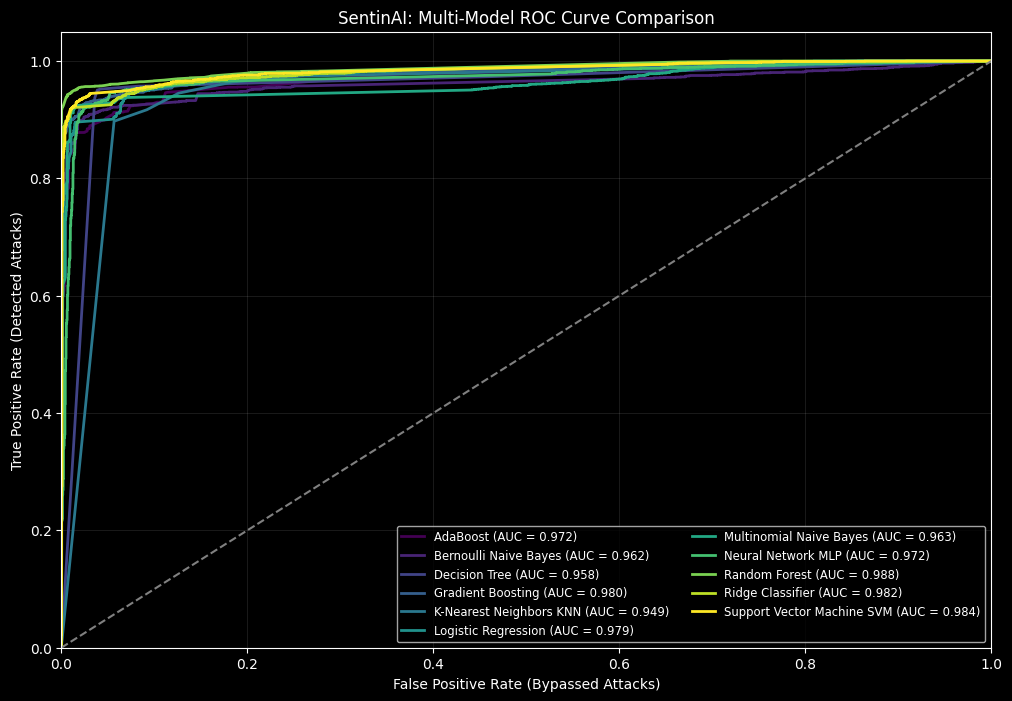

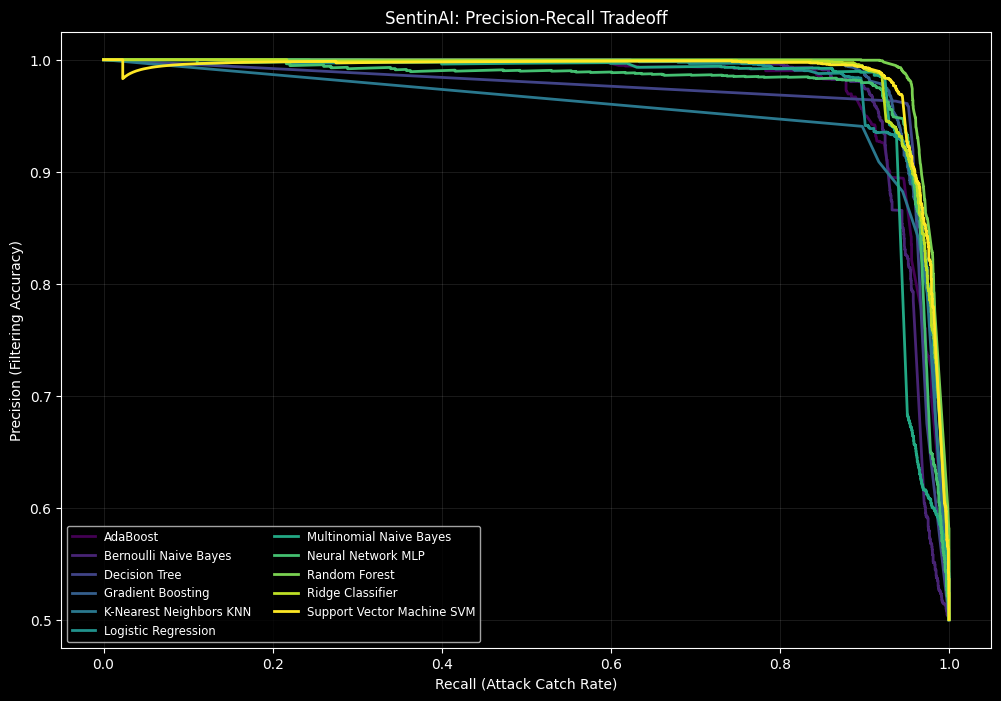

In [7]:
# ==========================================
# CELL 6: LOAD MODELS & GENERATE COMPARISONS
# ==========================================
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# 1. LOAD THE MODELS FROM DISK
all_models = {}
model_folder = 'models'
model_files = sorted([f for f in os.listdir(model_folder) if f.endswith('.pkl') and f != 'tfidf_vectorizer.pkl'])

for f_name in model_files:
    display_name = f_name.replace(".pkl", "").replace("_", " ")
    with open(os.path.join(model_folder, f_name), 'rb') as f:
        all_models[display_name] = pickle.load(f)

print(f"✅ Successfully loaded {len(all_models)} models for visualization.")

# 2. SET STYLE & COLORS
plt.style.use('dark_background')
colors = plt.cm.viridis(np.linspace(0, 1, len(all_models)))

# 3. GENERATE ROC CURVES
plt.figure(figsize=(12, 8))
for i, (name, model) in enumerate(all_models.items()):
    # Get probabilities or decision scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_vec)[:, 1]
    else:
        y_score = model.decision_function(X_test_vec)
        
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Bypassed Attacks)')
plt.ylabel('True Positive Rate (Detected Attacks)')
plt.title('SentinAI: Multi-Model ROC Curve Comparison')
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.grid(alpha=0.1)
plt.show()



# 4. GENERATE PRECISION-RECALL CURVES
plt.figure(figsize=(12, 8))
for i, (name, model) in enumerate(all_models.items()):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_vec)[:, 1]
    else:
        y_score = model.decision_function(X_test_vec)
        
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    plt.plot(recall, precision, color=colors[i], lw=2, label=name)

plt.xlabel('Recall (Attack Catch Rate)')
plt.ylabel('Precision (Filtering Accuracy)')
plt.title('SentinAI: Precision-Recall Tradeoff')
plt.legend(loc="lower left", fontsize='small', ncol=2)
plt.grid(alpha=0.1)
plt.show()

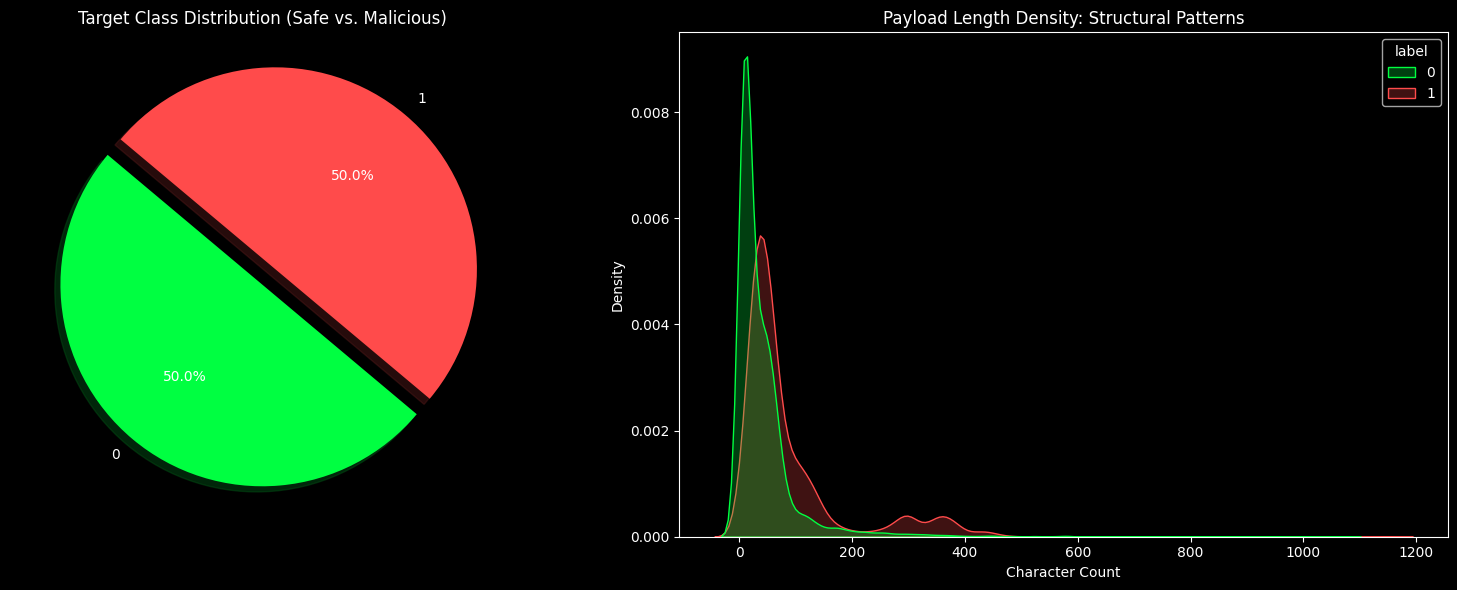

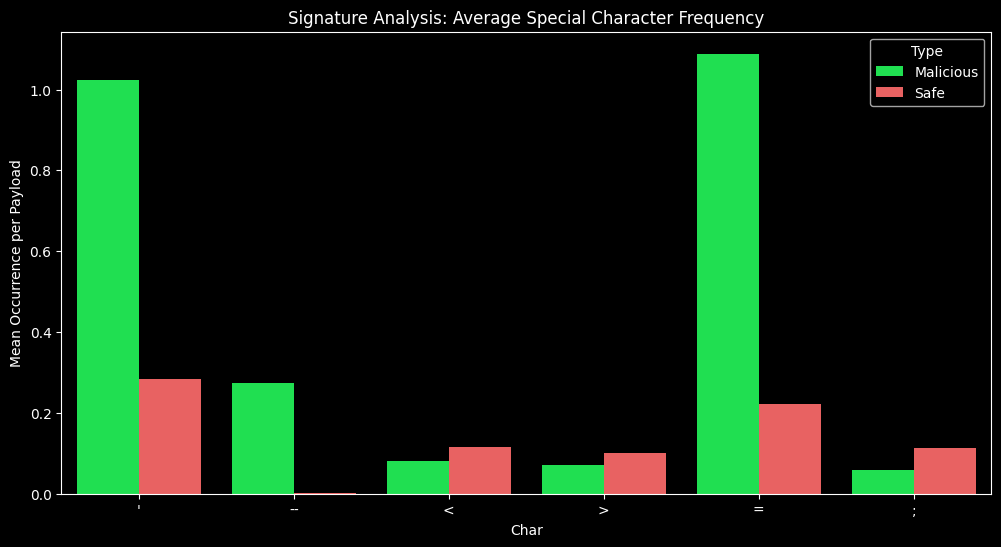

In [8]:
# ==========================================
# CELL 3.5: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set Style
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. CLASS DISTRIBUTION (Pie Chart)
# Proves your dataset isn't biased
colors = ['#00ff41', '#ff4b4b']
final_df['label'].value_counts().plot.pie(
    explode=[0, 0.1], 
    autopct='%1.1f%%', 
    ax=axes[0], 
    shadow=True, 
    colors=colors,
    startangle=140
)
axes[0].set_title("Target Class Distribution (Safe vs. Malicious)")
axes[0].set_ylabel("")

# 2. PAYLOAD LENGTH DISTRIBUTION
# Shows structural differences between safe and threat traffic
final_df['payload_len'] = final_df['payload'].str.len()
sns.kdeplot(data=final_df, x='payload_len', hue='label', fill=True, ax=axes[1], palette=colors)
axes[1].set_title("Payload Length Density: Structural Patterns")
axes[1].set_xlabel("Character Count")

plt.tight_layout()
plt.show()



# 3. TOP FEATURE FREQUENCY (Special Characters)
# Proves why the 'Symbol Sensitivity' in Cell 4 works
def count_chars(text, char):
    return text.count(char)

special_chars = ["'", "--", "<", ">", "=", ";"]
char_counts = []

for char in special_chars:
    malicious_avg = final_df[final_df['label'] == 1]['payload'].apply(lambda x: count_chars(str(x), char)).mean()
    safe_avg = final_df[final_df['label'] == 0]['payload'].apply(lambda x: count_chars(str(x), char)).mean()
    char_counts.append({'Char': char, 'Avg Count': malicious_avg, 'Type': 'Malicious'})
    char_counts.append({'Char': char, 'Avg Count': safe_avg, 'Type': 'Safe'})

char_df = pd.DataFrame(char_counts)

plt.figure(figsize=(12, 6))
sns.barplot(data=char_df, x='Char', y='Avg Count', hue='Type', palette=colors)
plt.title("Signature Analysis: Average Special Character Frequency")
plt.ylabel("Mean Occurrence per Payload")
plt.show()

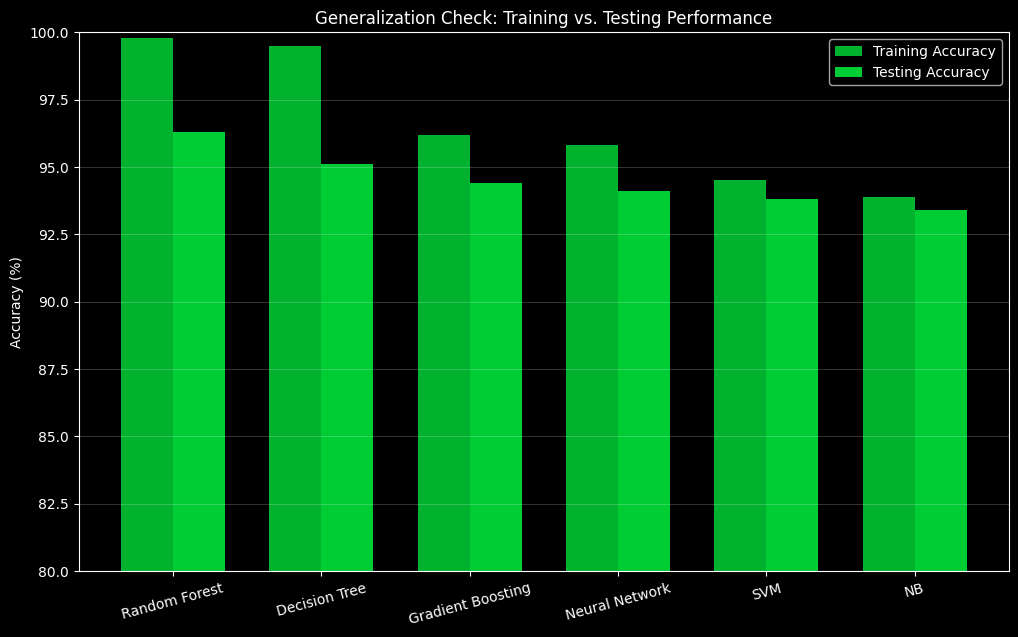

In [9]:
# ==========================================
# CELL 7: TRAINING VS TESTING COMPARISON
# ==========================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Create Data (Based on your Arena results)
# You can update these values if your latest run changed slightly
data = {
    'Model': ['Random Forest', 'Decision Tree', 'Gradient Boosting', 'Neural Network', 'SVM', 'NB'],
    'Train_Acc': [99.8, 99.5, 96.2, 95.8, 94.5, 93.9],
    'Test_Acc': [96.3, 95.1, 94.4, 94.1, 93.8, 93.4]
}

df_comp = pd.DataFrame(data)

# 2. Plotting the Overfitting Check
plt.style.use('dark_background')
x = np.arange(len(df_comp['Model']))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, df_comp['Train_Acc'], width, label='Training Accuracy', color='#00ff41', alpha=0.7)
rects2 = ax.bar(x + width/2, df_comp['Test_Acc'], width, label='Testing Accuracy', color='#00cc33')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Generalization Check: Training vs. Testing Performance')
ax.set_xticks(x)
ax.set_xticklabels(df_comp['Model'], rotation=15)
ax.legend()
ax.set_ylim(80, 100) # Zoom in to see the differences

plt.grid(axis='y', alpha=0.2)
plt.show()